# Generative AI models comparison: Constant Uniform dataset

### Setup

In [1]:
from google.colab import drive
import os
import sys
import torch

drive.mount('/content/drive')
PROJECT_PATH = '/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 1/results/notebook'
%cd "{PROJECT_PATH}"

BASE_DIR = os.path.abspath("..")
DATA_DIR = os.path.join(BASE_DIR, "data")
IMAGE_DIR = os.path.join(BASE_DIR, "saved_images")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n[INFO] Running on device: {device}\n")

Mounted at /content/drive
/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 1/results/notebook

[INFO] Running on device: cpu



In [2]:
from utils import (
    load_data,
    extract_generated_functions,
    save_image,
)

from utils_plots import (
    plot_function_grid,
    plot_forward_processes,
    plot_generation_processes,
)

from metrics import plot_constant_uniform_metrics

### Load saved results

In [3]:
# data_train
keys = ["data", "seed", "x_inf", "x_sup", "f_min_value", "f_max_value"]
data_train, seed, x_inf, x_sup, f_min_value, f_max_value = load_data(DATA_DIR, "dataset_samples.pt", keys)
axis_x = torch.linspace(x_inf, x_sup, data_train.shape[-1])
print(data_train.shape)

torch.Size([2000, 1, 128])


In [4]:
# flow matching

# interpolation process
keys = ["data", "t_0", "t_end", "t_eps"]
flow_interpolation, t_0, t_end, t_eps_flow = load_data(DATA_DIR, "forward_flow_interpolation.pt", keys)
print(flow_interpolation.shape)

# generation process
keys = ["data", "seed"]
flow_generation, seed = load_data(DATA_DIR, "generated_flow_samples.pt", keys)
print(flow_generation.shape)

torch.Size([2000, 100, 1, 128])
torch.Size([2000, 100, 1, 128])


In [5]:
# isotropic diffusion

# forward process
keys = ["data", "t_0", "t_end", "t_eps"]
forward_diffusion, _, _, t_eps_diffusion= load_data(DATA_DIR, "forward_diffusion_process.pt", keys)
print(forward_diffusion.shape)

# generation process
keys = ["data", "seed"]
diffusion_generation, seed = load_data(DATA_DIR, "generated_diffusion_samples.pt", keys)
print(diffusion_generation.shape)

torch.Size([2000, 100, 1, 128])
torch.Size([2000, 101, 1, 128])


### Extract generated functions

In [6]:
# flow matching

flow_samples = extract_generated_functions(generated_samples=flow_generation)
print(flow_samples.shape)

# diffusion

diffusion_samples = extract_generated_functions(generated_samples=diffusion_generation)
print(diffusion_samples.shape)

torch.Size([2000, 1, 128])
torch.Size([2000, 1, 128])


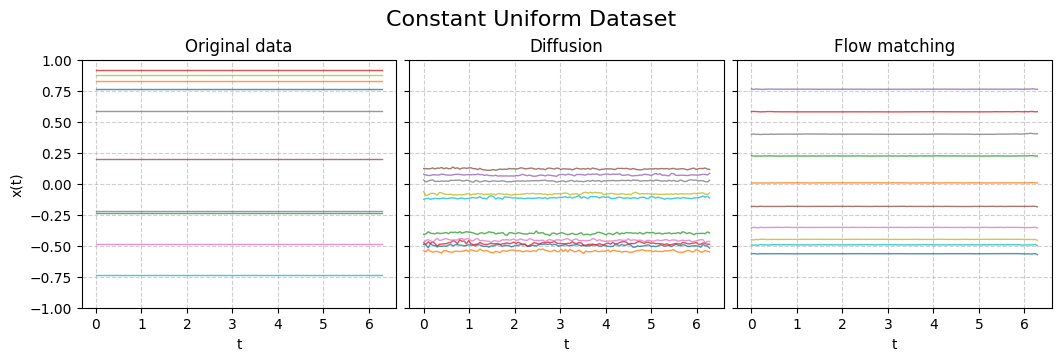

In [7]:
fig_samples = plot_function_grid({"Original data": data_train, "Diffusion": diffusion_samples, "Flow matching": flow_samples},
                         axis_x=axis_x, seed=seed, mode="overlapped", n_samples=10, suptitle="Constant Uniform Dataset")

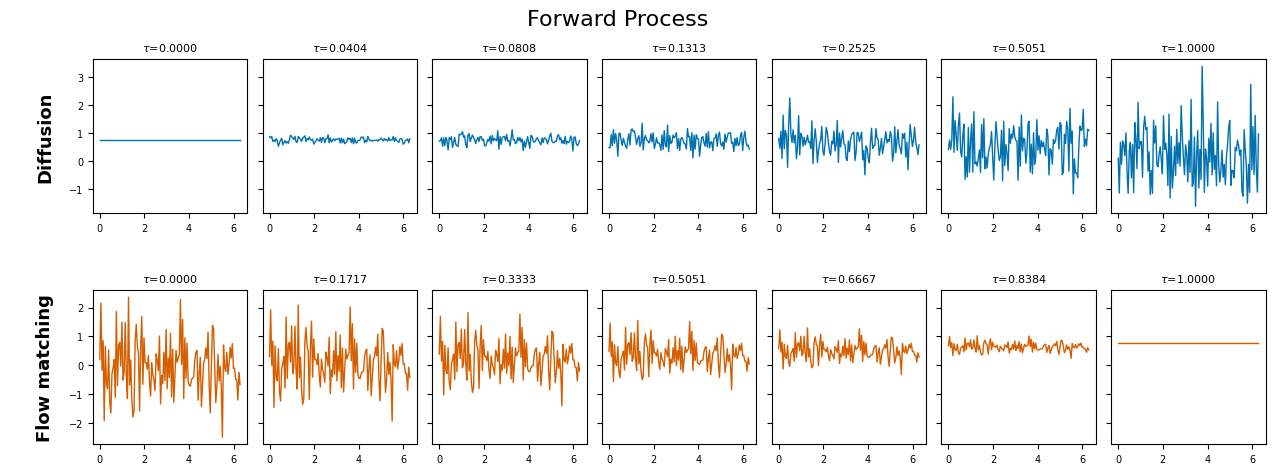

In [8]:
MODEL_COLORS = {
    "Original data": "#4D4D4D",
    "Diffusion": "#0072B2",
    "Flow matching": "#D55E00",
}

fig_forward = plot_forward_processes(
    forward_diffusion,
    flow_interpolation,
    axis_x,
    t_start_diffusion=t_0,
    t_end_diffusion=t_end,
    t_start_flow=t_0,
    t_end_flow=t_end,
    num_steps=7, n_samples=1, cell_size=(3.0, 3.0),
    suptitle="Forward Process",
    colors=MODEL_COLORS,
)

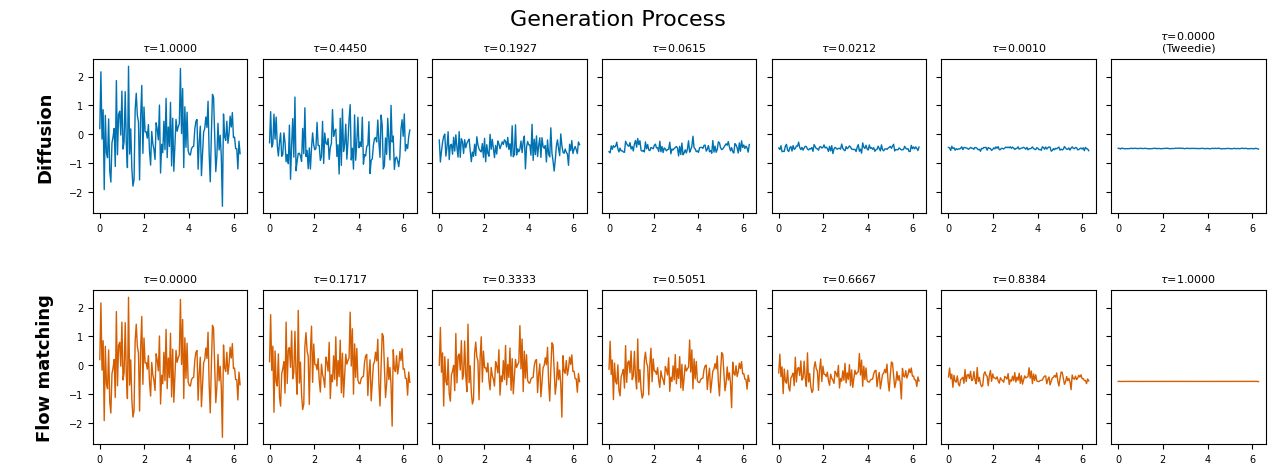

In [9]:
fig_generation = plot_generation_processes(
    diffusion_generation,
    flow_generation,
    axis_x,
    t_start_diffusion=t_end,
    t_end_diffusion=t_eps_diffusion,
    t_start_flow=t_0,
    t_end_flow=t_end,
    num_steps=7, n_samples=1, cell_size=(3.0, 3.0),
    suptitle="Generation Process",
    colors=MODEL_COLORS,
)

### Metrics comparison

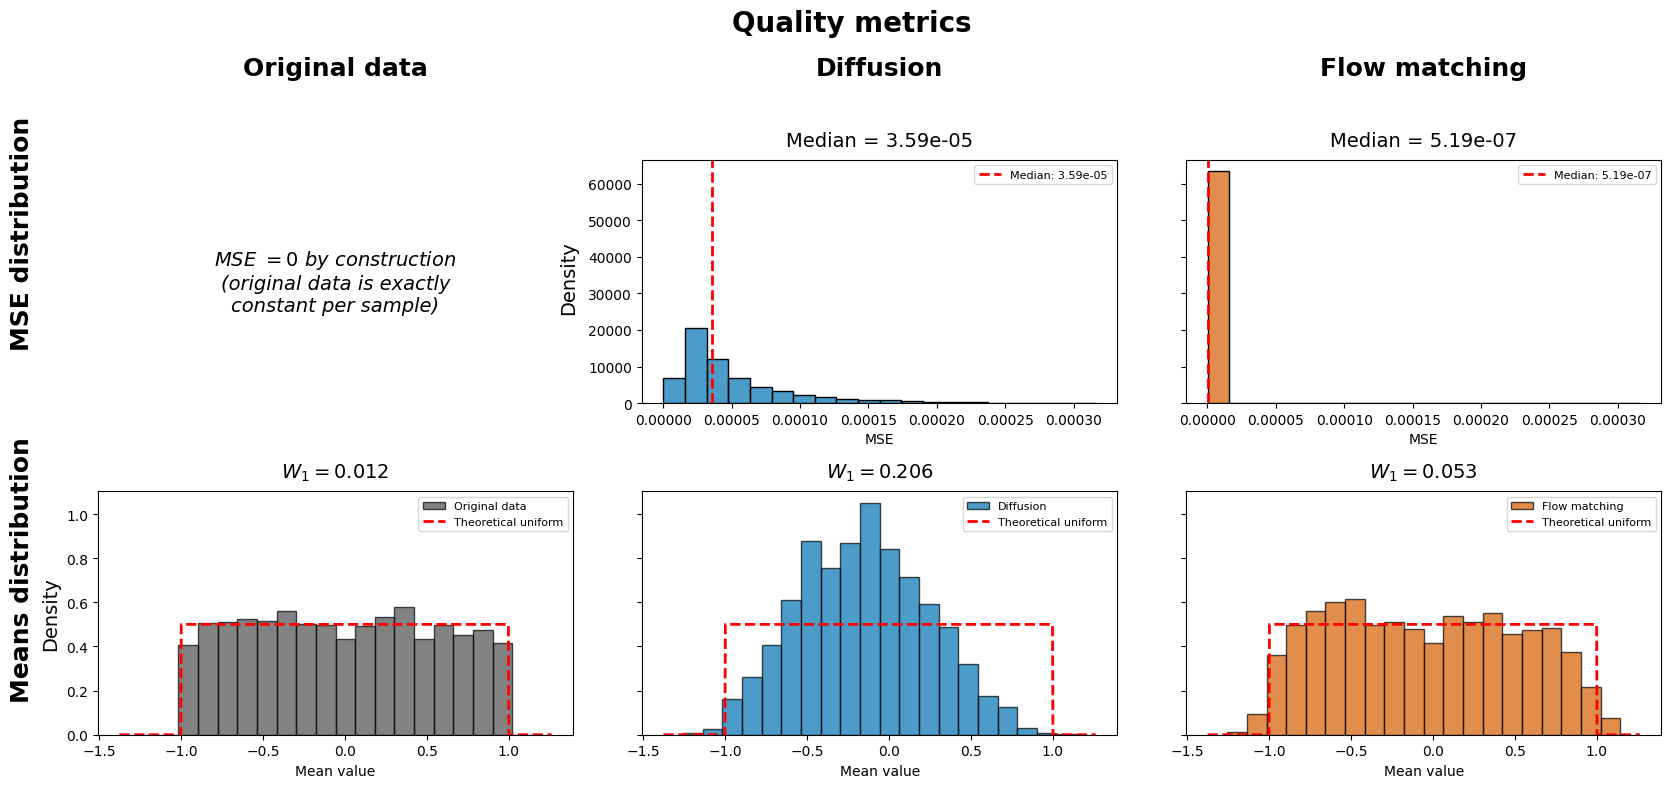

In [10]:
models = {
    "Original data": {"samples": data_train, "compute_mse": False},
    "Diffusion": {"samples": diffusion_samples},
    "Flow matching": {"samples": flow_samples},
}
fig_metrics = plot_constant_uniform_metrics(models, theoretical_min=f_min_value, theoretical_max=f_max_value,cell_size=(5.5, 4.0), colors=MODEL_COLORS)

In [12]:
save_image(fig_samples, IMAGE_DIR, "fig_constant_samples.pdf")
save_image(fig_forward, IMAGE_DIR, "fig_constant_forward.pdf")
save_image(fig_generation, IMAGE_DIR, "fig_constant_generation.pdf")
save_image(fig_metrics, IMAGE_DIR, "fig_constant_metrics.pdf")

Saved -> /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 1/results/saved_images/fig_constant_samples.pdf
Saved -> /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 1/results/saved_images/fig_constant_forward.pdf
Saved -> /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 1/results/saved_images/fig_constant_generation.pdf
Saved -> /content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 1/results/saved_images/fig_constant_metrics.pdf


PosixPath('/content/drive/MyDrive/Trabajo Fin de Máster/Code/Experiment 1/results/saved_images/fig_constant_metrics.pdf')